<a href="https://colab.research.google.com/github/petercloud23/Upload_ArquivoLocal_To_GoogleDrive/blob/main/UploadToDrive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Conectando o Google Drive usando IDEs externas:*

# Passo 1: Configurar a API do Google Drive no Google Cloud Console

Para permitir que sua aplicação Python no PyCharm interaja com o Google Drive, você precisa habilitar a API do Google Drive e obter credenciais de acesso. Siga estes passos:

Acesse o Google Cloud Console: Vá para https://console.cloud.google.com/ e faça login com sua conta Google.
Crie um novo projeto (ou selecione um existente): No menu superior, clique no seletor de projeto e crie um novo projeto ou escolha um projeto existente para associar a esta aplicação.
Habilite a API do Google Drive:
No menu de navegação lateral, vá para "APIs e serviços" > "Biblioteca".
Procure por "Google Drive API".
Clique na API do Google Drive e, em seguida, clique no botão "Ativar".

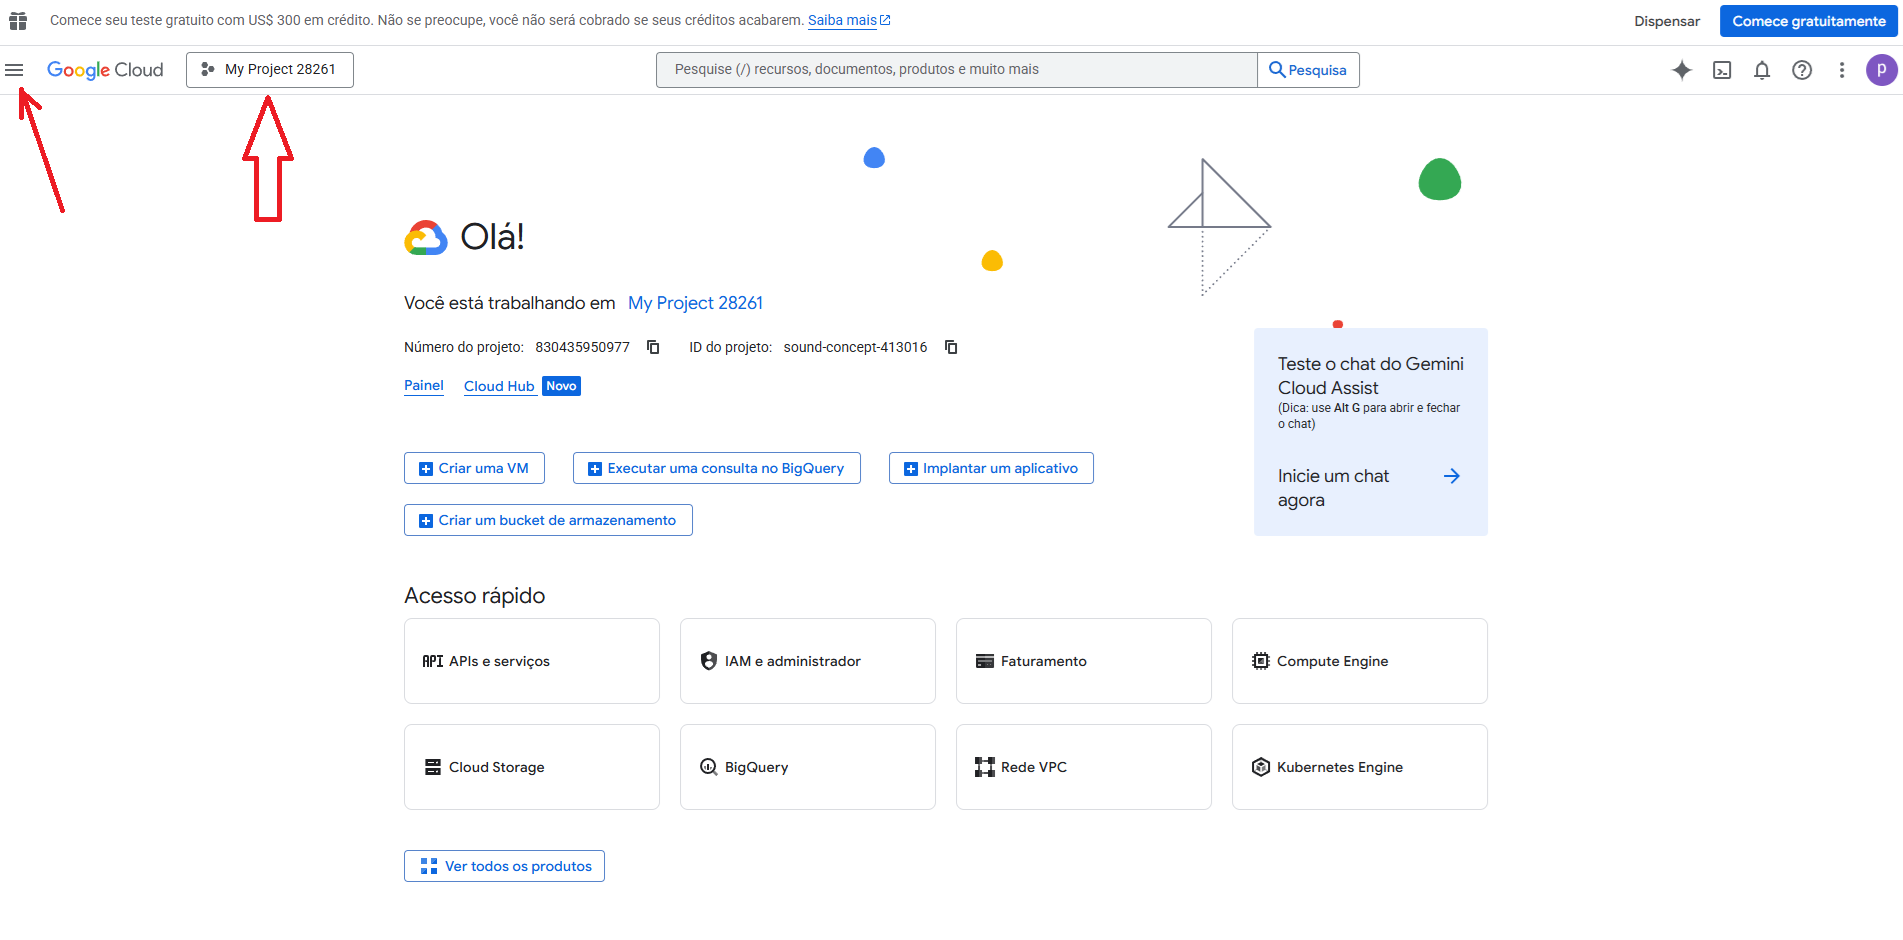

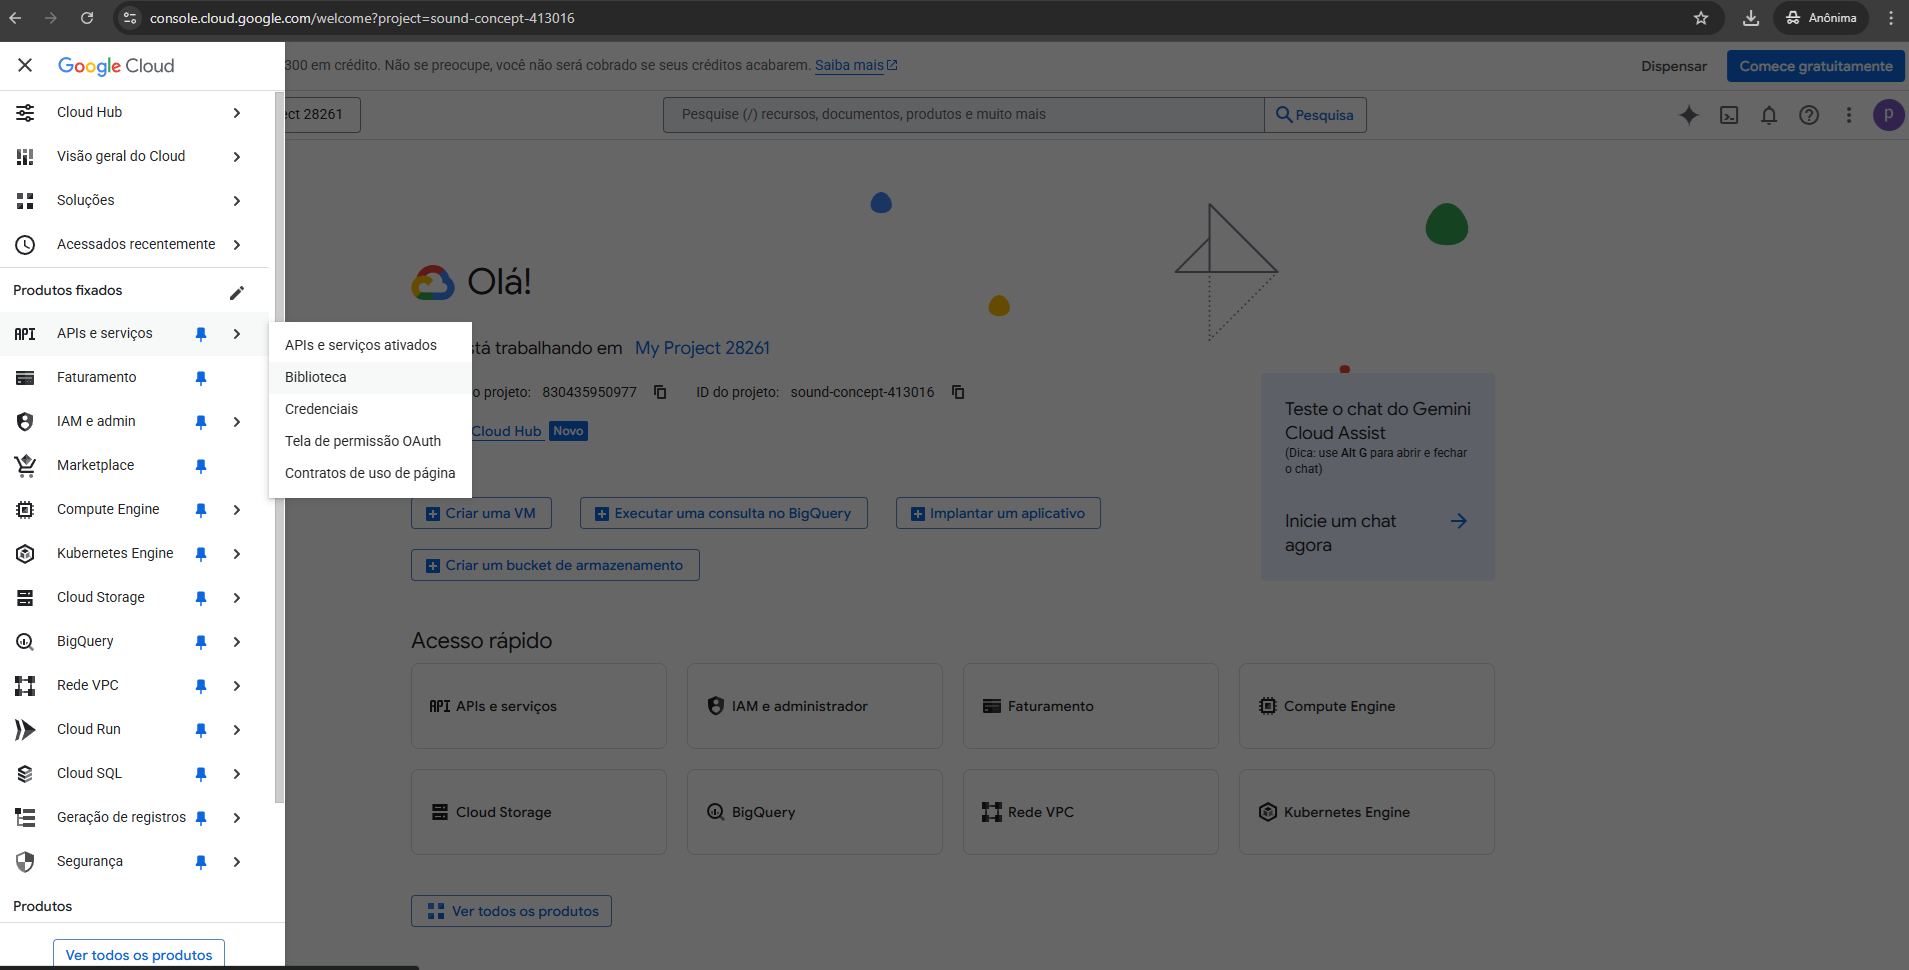

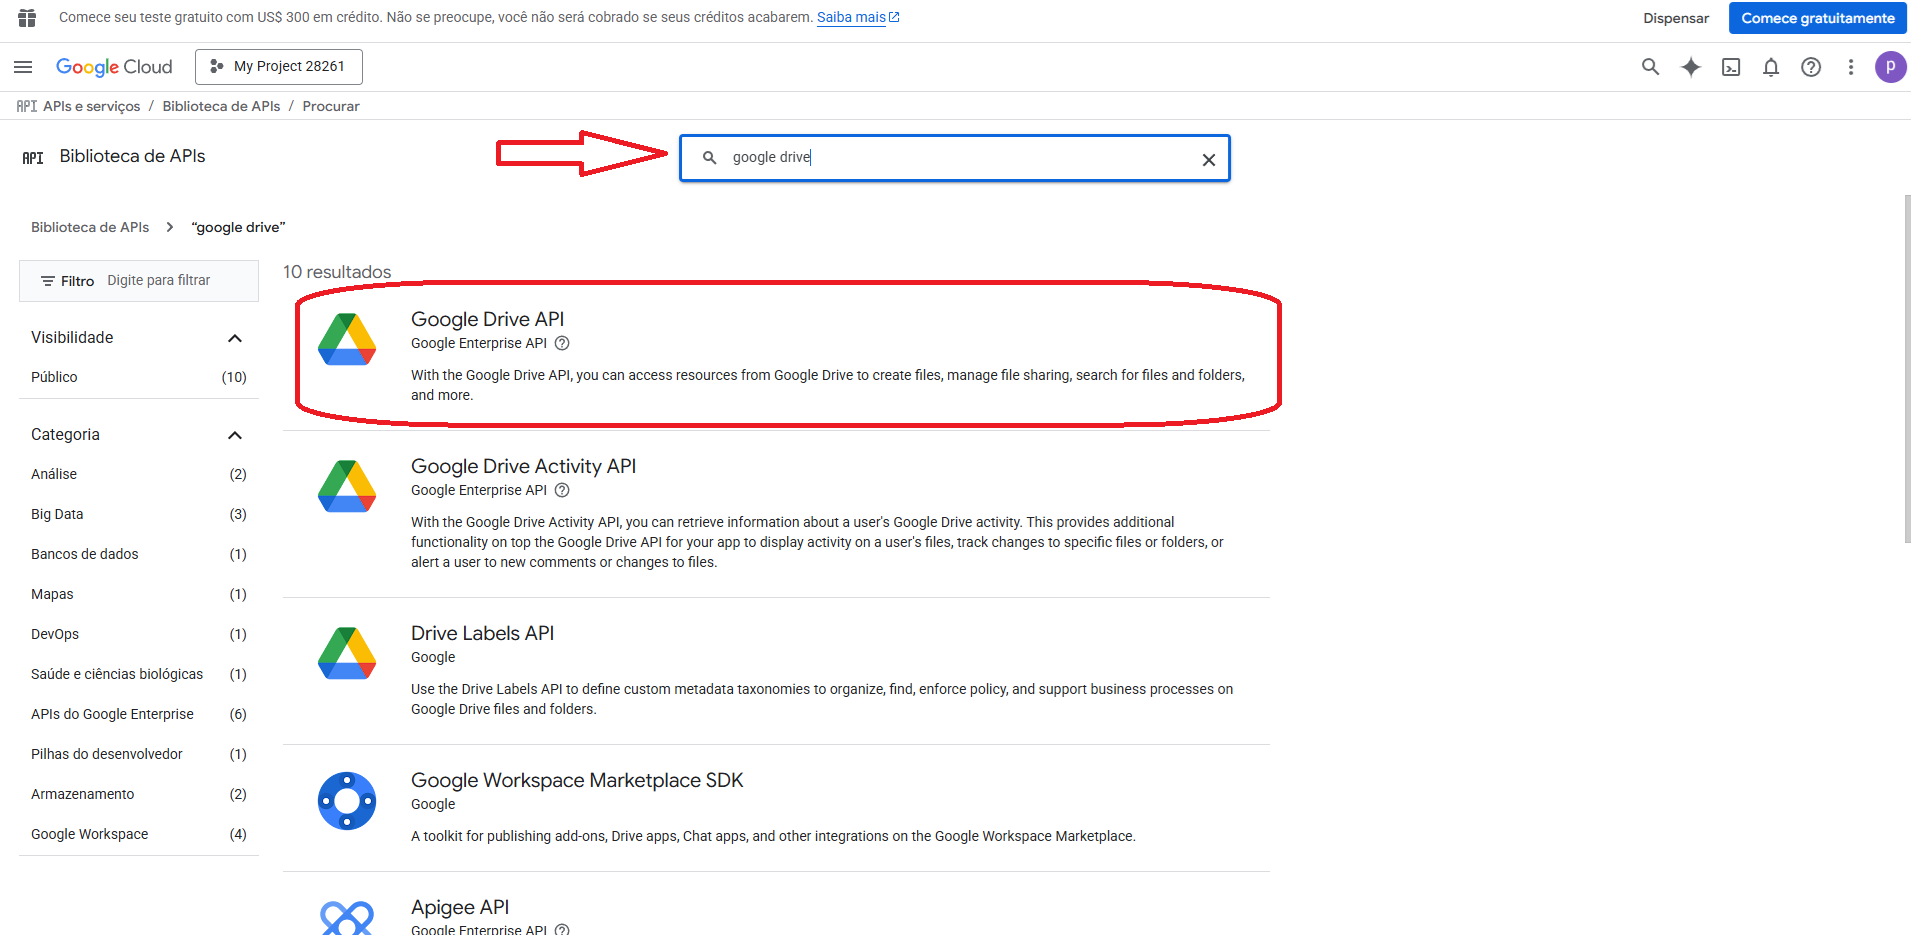

**Crie Credenciais**:
    *   No menu de navegação lateral, vá para "APIs e serviços" > "Credenciais".
    *   Clique em "Criar credenciais".
    *   Escolha "ID do cliente OAuth".
    *   Se for solicitado a configurar a tela de consentimento OAuth, siga as instruções. Você precisará definir o nome da sua aplicação e outras informações básicas.
    *   Para o "Tipo de aplicativo", escolha "Aplicativo de desktop".
    *   Dê um nome ao seu cliente OAuth (por exemplo, "Upload Drive PyCharm").
    *   Clique em "Criar".

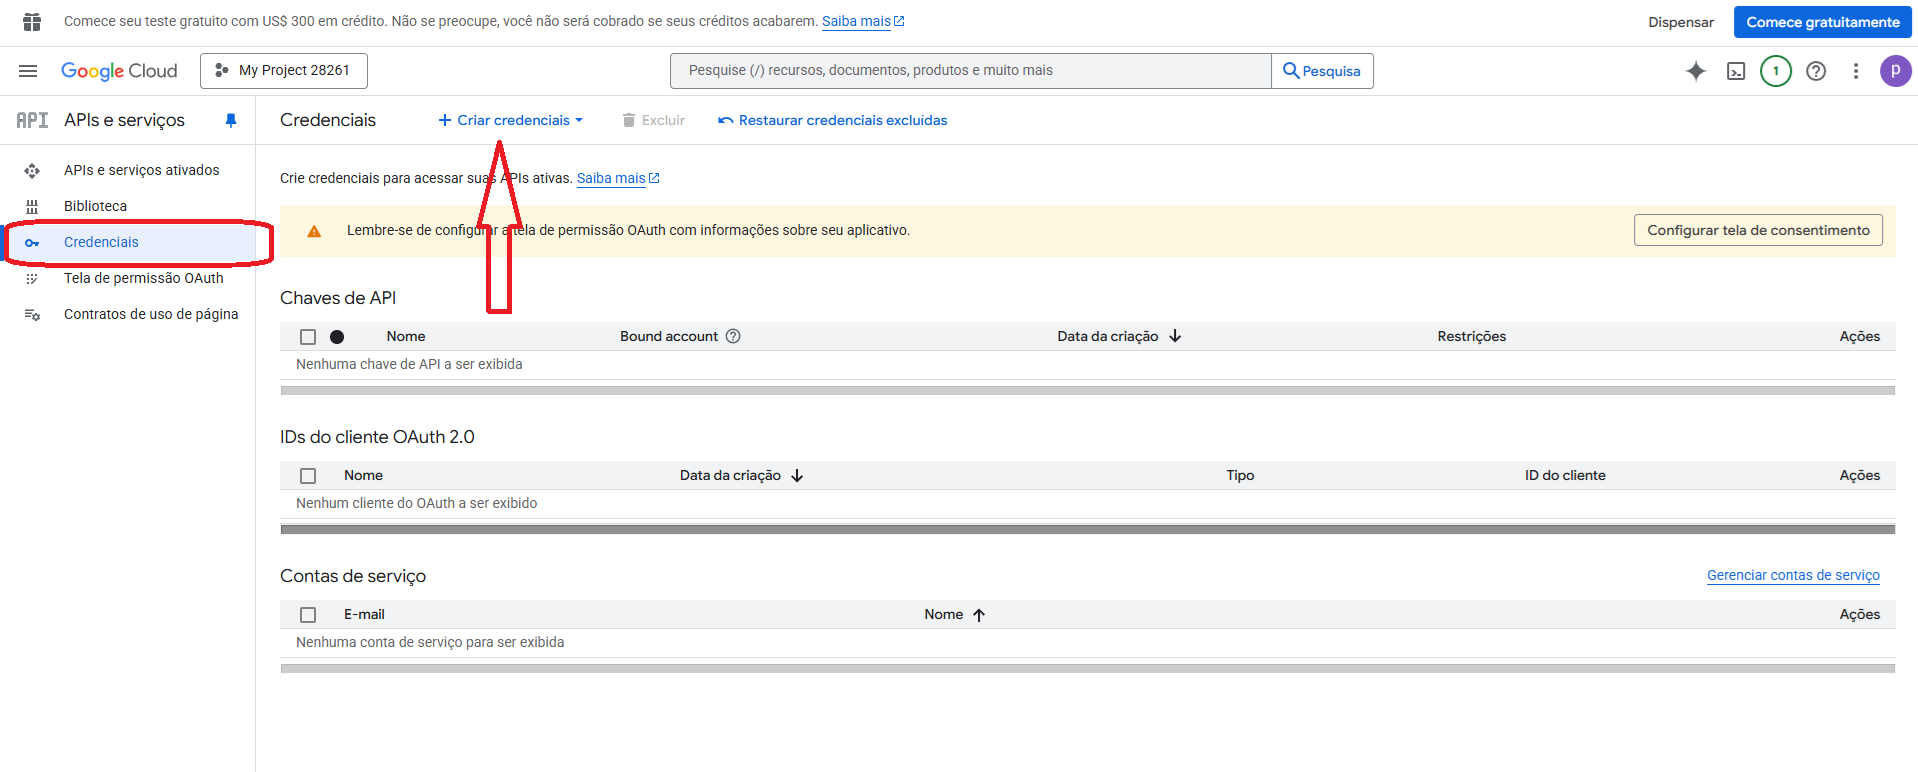







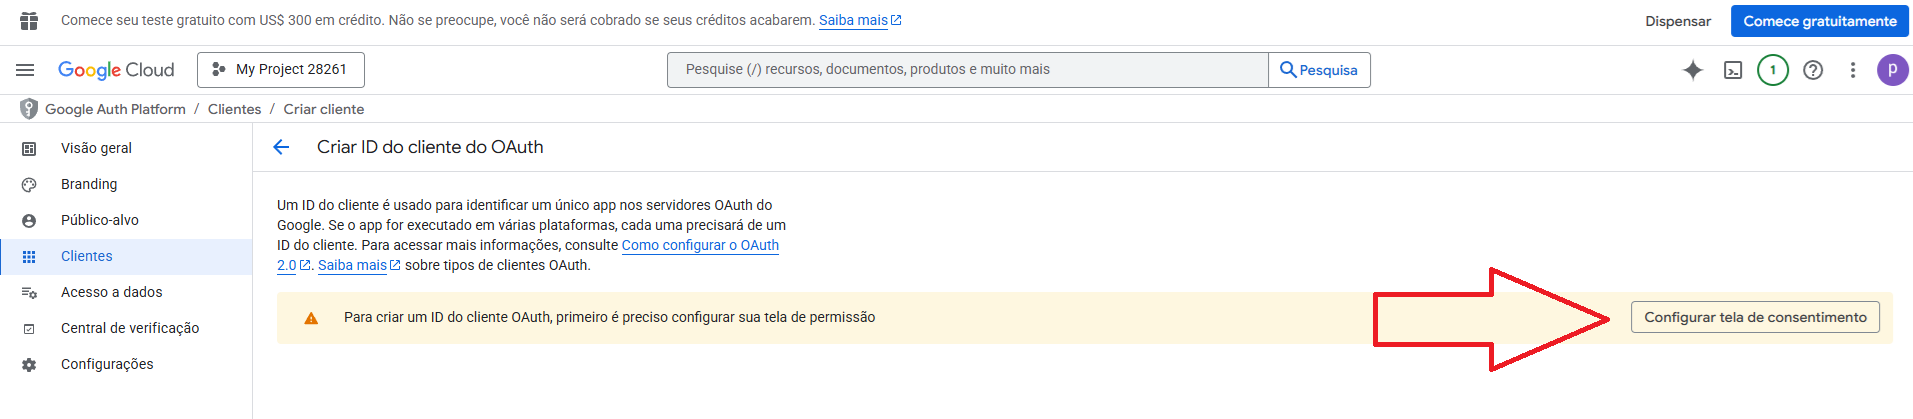

Quando você cria um projeto no Google Cloud Console e configura uma tela de consentimento OAuth (para usar com InstalledAppFlow como no seu script):

Por padrão, a aplicação fica com o status “Em teste”.

Nesse modo, apenas e-mails explicitamente adicionados como “usuários de teste” na tela de consentimento podem autorizar o app.

Se tentar autenticar com qualquer outro e-mail → Erro 403: access_denied.

✅ Como resolver

🔹 1. Vá até o Google Cloud Console

No projeto onde você criou o credentials.json.

🔹 2. Acesse "Tela de consentimento OAuth"

No menu lateral esquerdo (em “APIs e serviços”).

🔹 3. Veja o status:

Se estiver como “Em teste”, só testadores podem logar.

Se quiser liberar para qualquer conta Google, você precisa publicar o app (clicar em “Publicar app”).

🔹 4. Opção 1 — Adicionar seu e-mail como testador

Mais simples e seguro durante o desenvolvimento:

Vá até a aba “Usuários de teste”.

Clique em “+ Adicionar usuários”.

Coloque o mesmo e-mail Google com o qual você está tentando fazer login.

Clique em Salvar.

Agora, ao rodar novamente o script, o login vai funcionar ✅

🔹 5. Opção 2 — Publicar o app

Se quiser usar em produção (ou com qualquer usuário):

No topo da tela de consentimento, clique em “Publicar app”.

Escolha “Publicar para qualquer usuário com uma Conta Google”.

Isso tira as restrições, mas só deve ser feito se você realmente pretende distribuir o app.

* Após configurar o consentimento, é hora de criar o Cliente de OAuth. Para o "Tipo de aplicativo", escolha "App de computador". * Dê um nome ao seu cliente OAuth (por exemplo, "Upload Drive PyCharm"). * Clique em "Criar".

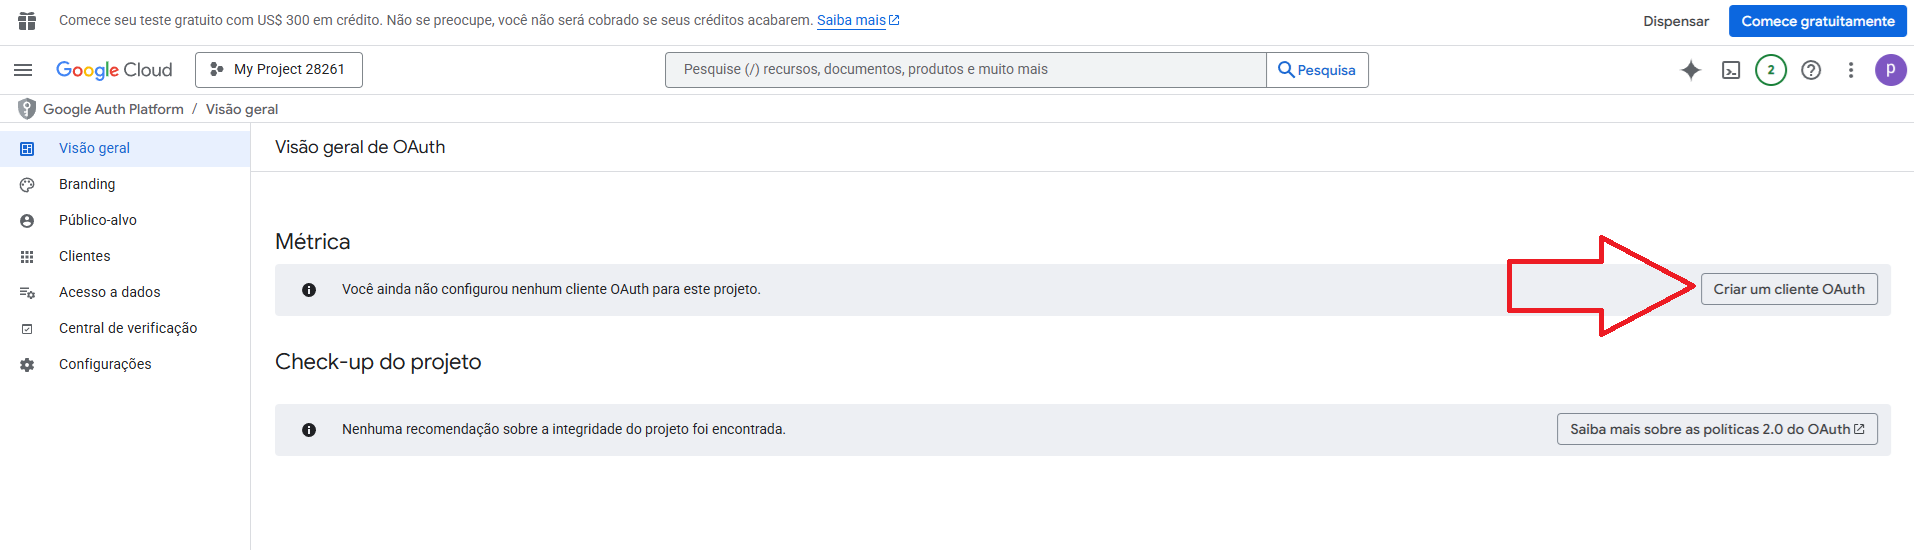

Baixe as Credenciais: Uma janela pop-up mostrará suas credenciais. Clique no botão "Fazer download do JSON" para baixar o arquivo json com a sua redencial. Salve este arquivo NO MESMO LOCAL do diretório do seu projeto no PyCharm, E RENOMEIE-O PARA 'credentials.json'. Este arquivo contém as informações que sua aplicação precisará para se autenticar.

Após completar estes passos, você terá o arquivo credentials.json necessário para o próximo passo: a instalação das bibliotecas Python.

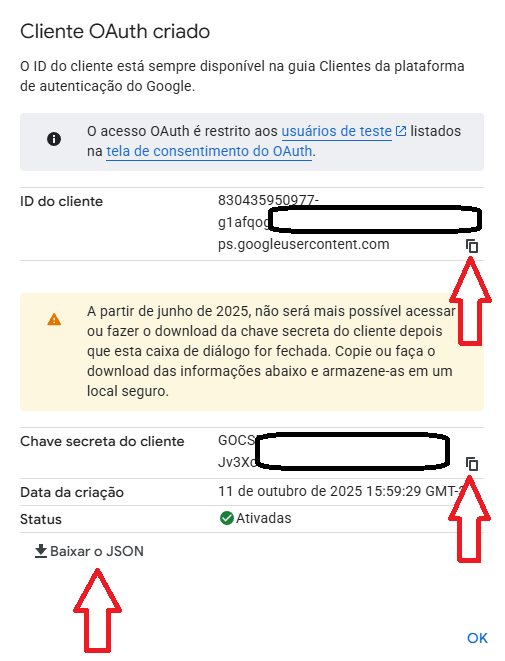

In [ ]:
# Instale as bibliotecas do Google Client para Python
pip install google-api-python-client google-auth-httplib2 google-auth-oauthlib

In [ ]:
import os.path
import io
from google.auth.transport.requests import Request
from google.oauth2.credentials import Credentials
from google_auth_oauthlib.flow import InstalledAppFlow
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload

# Se modificar esses escopos, delete o arquivo token.json.
# Os escopos definem quais permissões sua aplicação terá no Google Drive.
SCOPES = ['https://www.googleapis.com/auth/drive.file'] # Permite gerenciar arquivos criados/abertos por esta app.
# SCOPES = ['https://www.googleapis.com/auth/drive'] # Permite gerenciar todos os arquivos no seu Drive (mais amplo)


def upload_basic():
    """Mostra como fazer upload de um arquivo para o Google Drive."""
    creds = None
    # O arquivo token.json armazena os tokens de atualização e acesso do usuário, e
    # é criado automaticamente quando o fluxo de autorização é concluído pela primeira vez.
    if os.path.exists('token.json'):
        creds = Credentials.from_authorized_user_file('token.json', SCOPES)
    # Se não houver credenciais válidas disponíveis, permita que o usuário faça login.
    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token:
            creds.refresh(Request())
        else:
            # O arquivo credentials.json deve estar no mesmo diretório do script.
            flow = InstalledAppFlow.from_client_secrets_file(
                'credentials.json', SCOPES)
            creds = flow.run_local_server(port=0)
        # Salva as credenciais para a próxima execução
        with open('token.json', 'w') as token:
            token.write(creds.to_json())

    try:
        service = build('drive', 'v3', credentials=creds)

        # --- Configuração do Arquivo para Upload ---
        # Substitua pelo caminho completo do arquivo que você quer fazer upload no seu computador.
        file_path = 'caminho/para/seu/arquivo/local.txt' # <-- ALTERE ESTA LINHA

        if not os.path.exists(file_path):
            print(f"Erro: Arquivo local não encontrado: {file_path}")
            return

        file_name = os.path.basename(file_path) # Obtém apenas o nome do arquivo

        # Metadados do arquivo para o Google Drive
        file_metadata = {'name': file_name}
        # Define o tipo de mídia do arquivo (MIME type). requests adivinha para você na maioria dos casos.
        media = MediaFileUpload(file_path, mimetype='text/plain',
                                resumable=True) # Adicione o mimetype apropriado

        # --- Realizar o Upload ---
        print(f"Fazendo upload de '{file_name}' para o Google Drive...")
        file = service.files().create(body=file_metadata, media_body=media,
                                        fields='id').execute()
        print(f"Arquivo '{file_name}' (ID: {file.get('id')}) enviado com sucesso!")

    except Exception as e:
        print(f'Ocorreu um erro: {e}')

if __name__ == '__main__':
    # Chame a função para iniciar o processo de upload
    upload_basic()

Antes de rodar o código acima, lembre-se de substituir na linha ' ', o caminho para o arquivo que deseja fazer o upload da sua máquina local para o Google Drive.
MAS ATENTENTE-SE: se estiver rodando o código no Windows, há a questão que no Python, a barra invertida (\) tem significado especial: ela indica caractere de escape (por exemplo, \n = nova linha, \t = tabulação).
Por isso, quando você coloca um caminho do Windows entre aspas sem ajustar isso, o Python tenta “interpretar” essas barras, e dá erro, então utilize um dos ajustes a seguir no caminho do seu arquivo:

In [ ]:
file_path = "C:\\Users\\Peterson\\PycharmProjects\\PythonProject\\Teste_UploadToDrive.txt"

OU

In [ ]:
file_path = r"C:\Users\Peterson\PycharmProjects\PythonProject\Teste_UploadToDrive.txt"

#usar string “raw” (prefixo r) diz ao Python para não interpretar as barras invertidas

OU

In [ ]:
file_path = "C:/Users/Peterson/PycharmProjects/PythonProject/Teste_UploadToDrive.txt"

#O Python entende automaticamente / como separador de caminho, mesmo no Windows (também funciona em Linux e macOS)

OU

In [ ]:
import os

file_path = os.path.join("C:", "Users", "Peterson", "PycharmProjects", "PythonProject", "Teste_UploadToDrive.txt")

#constroi o caminho automaticamente com o módulo os.